# BA Scenario Metrics Generation

This notebook is a self-contained reconstruction of the packaged MISO scenario metrics in `paper_data/data/wtk_bchrrr_nsrdb_2007_2023`. Every transformation is shown here; the notebook does not call project-specific generation helpers.

The process data flow is:

```text
MISO settings and metadata
    -> hourly load/wind-CF/solar-CF ingredients
    -> one aligned base table
    -> scenario capacity definitions
    -> one packaged-style BA scenario-metrics table
    -> consistency check against paper_data/data/wtk_bchrrr_nsrdb_2007_2023/ba_scenario_metrics
```

The additional comparisons apply the same ingredients to `MISO_SUBREGION_SUM`, point to the authoritative state workflows, and retain the original MISO/EIA plotting comparison.


## Imports And Package Setup

This cell defines the notebook's shared file locations. Inputs are read from `paper_data/data/wtk_bchrrr_nsrdb_2007_2023`, while notebook-created CSVs are written under `paper_data/notebook_outputs/data_flow/ba_scenario_metrics_generation` so packaged inputs stay unchanged.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Paths are relative to this notebook's location in paper_data/data_flow.
SOURCE_BUNDLE = "wtk_bchrrr_nsrdb"
PERIOD_LABEL = "2007_2023"
DATA_ROOT = Path("../data") / f"{SOURCE_BUNDLE}_{PERIOD_LABEL}"
SOURCE_INPUTS = Path("../data/source_inputs")
# Notebook products stay separate from the immutable packaged inputs.
OUTPUT_DIR = Path("../notebook_outputs/data_flow/ba_scenario_metrics_generation")
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"Expected to find the packaged run data folder at ../data/{SOURCE_BUNDLE}_{PERIOD_LABEL}. "
        "Open this notebook from inside paper_data/data_flow."
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Process: Recreate Packaged BA Scenario Metrics

Steps 1-5 recreate the packaged MISO scenario-metrics table. Each step keeps the important intermediate table visible so the calculation can be reviewed directly.


### Step 1: Read Selected BA Inputs

Step 1 reads MISO's installed capacities, loss assumptions, and three hourly ingredient files.


In [2]:
# These two settings identify both the worked example and its installed-capacity vintage.
BA_CODE = "MISO"
GENERATOR_SET_YEAR = 2024

metadata_path = Path("../manifests") / f"ba_scenario_metric_metadata_manifest_{SOURCE_BUNDLE}_{PERIOD_LABEL}.csv"
ba_scenario_metric_metadata = pd.read_csv(metadata_path)
ba_metadata = ba_scenario_metric_metadata[ba_scenario_metric_metadata["ba_code"].eq(BA_CODE)].copy()

# Installed capacities are BA-level facts repeated across the manifest's metric rows.
ba_metadata_summary = ba_metadata.iloc[0]
wind_capacity_mw = float(ba_metadata_summary["installed_wind_capacity_mw"])
solar_capacity_mw = float(ba_metadata_summary["installed_solar_capacity_mw"])
total_capacity_mw = wind_capacity_mw + solar_capacity_mw

# Convert percentage losses to the multiplier applied to each hourly raw CF.
loss_assumptions = pd.read_csv(SOURCE_INPUTS / "net_load_loss_assumptions" / f"net_load_loss_assumptions_{PERIOD_LABEL}.csv")
ba_loss = loss_assumptions.set_index("ba").loc[BA_CODE]
wind_loss_multiplier = 1.0 - float(ba_loss["wind_loss_pct"]) / 100.0
solar_loss_multiplier = 1.0 - float(ba_loss["solar_loss_pct"]) / 100.0

# Each file contributes one physical ingredient: demand in MW or renewable availability as CF.
component_paths = {
    "load_mw": DATA_ROOT / "ba_load" / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_load.csv",
    "wind_cf": DATA_ROOT / "ba_wind_cf" / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_wind_cf.csv",
    "solar_cf": DATA_ROOT / "ba_solar_cf" / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_solar_cf.csv",
}

component_tables = {
    # Parsing time here gives all later joins one common UTC-aware key.
    column: pd.read_csv(path, parse_dates=["time_utc"])
    for column, path in component_paths.items()
}
component_sources = pd.DataFrame(
    [{"ingredient": column, "path": path.relative_to(Path("..")).as_posix()} for column, path in component_paths.items()]
)

print(f"Selected BA: {BA_CODE}")
display(ba_metadata[["ba_code", "metric", "scenario", "wind_capacity_mw", "solar_capacity_mw", "total_capacity_mw", "ba_type", "has_load", "has_wind", "has_solar", "has_renewable"]])
display(component_sources)
display(pd.DataFrame([{"wind_loss_multiplier": wind_loss_multiplier, "solar_loss_multiplier": solar_loss_multiplier, "installed_wind_capacity_mw": wind_capacity_mw, "installed_solar_capacity_mw": solar_capacity_mw, "installed_total_capacity_mw": total_capacity_mw}]))


Selected BA: MISO


,ba_code,metric,scenario,wind_capacity_mw,solar_capacity_mw,total_capacity_mw,ba_type,has_load,has_wind,has_solar,has_renewable
185,MISO,load_mw,installed_2024,32150.7,13574.9,45725.6,load + wind + solar,True,True,True,True
186,MISO,net_load_mw__installed_2024,installed_2024,32150.7,13574.9,45725.6,load + wind + solar,True,True,True,True
187,MISO,renew_cf_equiv__installed_2024,installed_2024,32150.7,13574.9,45725.6,load + wind + solar,True,True,True,True
188,MISO,net_load_mw__split_w00_s100,split_w00_s100,0.0,45725.6,45725.6,load + wind + solar,True,True,True,True
189,MISO,renew_cf_equiv__split_w00_s100,split_w00_s100,0.0,45725.6,45725.6,load + wind + solar,True,True,True,True
190,MISO,net_load_mw__split_w25_s75,split_w25_s75,11431.4,34294.2,45725.6,load + wind + solar,True,True,True,True
191,MISO,renew_cf_equiv__split_w25_s75,split_w25_s75,11431.4,34294.2,45725.6,load + wind + solar,True,True,True,True
192,MISO,net_load_mw__split_w50_s50,split_w50_s50,22862.8,22862.8,45725.6,load + wind + solar,True,True,True,True
193,MISO,renew_cf_equiv__split_w50_s50,split_w50_s50,22862.8,22862.8,45725.6,load + wind + solar,True,True,True,True
194,MISO,net_load_mw__split_w75_s25,split_w75_s25,34294.2,11431.4,45725.6,load + wind + solar,True,True,True,True


,ingredient,path
0,load_mw,data/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_w...
1,wind_cf,data/wtk_bchrrr_nsrdb_2007_2023/ba_wind_cf/MIS...
2,solar_cf,data/wtk_bchrrr_nsrdb_2007_2023/ba_solar_cf/MI...


,wind_loss_multiplier,solar_loss_multiplier,installed_wind_capacity_mw,installed_solar_capacity_mw,installed_total_capacity_mw
0,1.0,1.0,32150.7,13574.9,45725.6


### Step 2: Build The Base Hourly Table

Step 2 aligns MISO load, wind CF, and solar CF on `time_utc`. The inner joins retain only hours present in all three inputs. Renewable losses are then applied as `adjusted_cf = raw_cf * (1 - loss_pct / 100)` before any scenario capacity is introduced.


In [3]:
# Inner joins define the common hourly support shared by load, wind, and solar.
base = (
    component_tables["load_mw"][["time_utc", "load_mw"]]
    .merge(component_tables["wind_cf"][["time_utc", "wind_cf"]], on="time_utc")
    .merge(component_tables["solar_cf"][["time_utc", "solar_cf"]], on="time_utc")
    .sort_values("time_utc")
    .reset_index(drop=True)
)
# Losses alter renewable availability once, before scenario capacities convert CF to MW.
base["wind_cf"] *= wind_loss_multiplier
base["solar_cf"] *= solar_loss_multiplier

print(f"Base hourly rows: {len(base):,}")
display(base.head(20))


Base hourly rows: 148,920


,time_utc,load_mw,wind_cf,solar_cf
0,2007-01-01 00:00:00+00:00,71102.71,0.939351,0.000000
1,2007-01-01 01:00:00+00:00,72102.05,0.943142,0.000000
2,2007-01-01 02:00:00+00:00,71748.53,0.959258,0.000000
3,2007-01-01 03:00:00+00:00,70095.67,0.957499,0.000000
4,2007-01-01 04:00:00+00:00,67768.04,0.961652,0.000000
5,2007-01-01 05:00:00+00:00,65281.03,0.957755,0.000000
6,2007-01-01 06:00:00+00:00,65130.19,0.948080,0.000000
7,2007-01-01 07:00:00+00:00,63450.92,0.942607,0.000000
8,2007-01-01 08:00:00+00:00,62517.47,0.936153,0.000000
9,2007-01-01 09:00:00+00:00,62335.02,0.929514,0.000000


### Step 3: Define Scenario Capacity Mixes

Step 3 defines MISO's installed-capacity scenario and five synthetic wind/solar splits. The installed scenario preserves the observed technology mix; each synthetic scenario reallocates the same total renewable nameplate capacity.

For every synthetic split, the wind and solar percentages are shares of the combined wind-plus-solar nameplate capacity. The combined nameplate total is held fixed; the percentages do not describe shares of hourly energy generation.


In [4]:
ARCHIVE_INSTALLED_SCENARIO = f"installed_{GENERATOR_SET_YEAR}"
# Synthetic names encode the wind/solar shares of total renewable nameplate capacity.
split_wind_pct = [0, 25, 50, 75, 100]
# Row 0 preserves installed wind and solar; the remaining rows hold their combined total fixed.
scenario_specs = pd.DataFrame(
    {
        "scenario": [ARCHIVE_INSTALLED_SCENARIO] + [f"split_w{wind:02d}_s{100 - wind:02d}" for wind in split_wind_pct],
        "wind_capacity_mw": [wind_capacity_mw] + [total_capacity_mw * wind / 100 for wind in split_wind_pct],
        "solar_capacity_mw": [solar_capacity_mw] + [total_capacity_mw * (100 - wind) / 100 for wind in split_wind_pct],
    }
)
# Percentage columns are descriptive labels used by the plot, not calculation inputs.
scenario_specs["total_capacity_mw"] = scenario_specs[["wind_capacity_mw", "solar_capacity_mw"]].sum(axis=1)
scenario_specs["wind_pct"] = 100 * scenario_specs["wind_capacity_mw"] / scenario_specs["total_capacity_mw"]
scenario_specs["solar_pct"] = 100 - scenario_specs["wind_pct"]
display(scenario_specs)


,scenario,wind_capacity_mw,solar_capacity_mw,total_capacity_mw,wind_pct,solar_pct
0,installed_2024,32150.7,13574.9,45725.6,70.312254,29.687746
1,split_w00_s100,0.0,45725.6,45725.6,0.000000,100.000000
2,split_w25_s75,11431.4,34294.2,45725.6,25.000000,75.000000
3,split_w50_s50,22862.8,22862.8,45725.6,50.000000,50.000000
4,split_w75_s25,34294.2,11431.4,45725.6,75.000000,25.000000
5,split_w100_s00,45725.6,0.0,45725.6,100.000000,0.000000


### Step 4: Calculate Scenario Metrics

Step 4 crosses the six capacity definitions with every hourly row, then applies the core equations: `generation_mw = adjusted_cf * capacity_mw`, `net_load_mw = load_mw - wind_mw - solar_mw`, and `renew_cf_equiv = (wind_mw + solar_mw) / total_capacity_mw`.


In [5]:
scenario_capacity_columns = ["scenario", "wind_capacity_mw", "solar_capacity_mw", "total_capacity_mw"]
# The cross join repeats every hour once for each of the six capacity portfolios.
notebook_scenarios = scenario_specs[scenario_capacity_columns].merge(base, how="cross")
# Technology generation equals loss-adjusted availability times scenario nameplate capacity.
notebook_scenarios["wind_mw"] = notebook_scenarios["wind_cf"] * notebook_scenarios["wind_capacity_mw"]
notebook_scenarios["solar_mw"] = notebook_scenarios["solar_cf"] * notebook_scenarios["solar_capacity_mw"]
renewable_mw = notebook_scenarios["wind_mw"] + notebook_scenarios["solar_mw"]
# Net load is residual demand; equivalent CF normalizes combined generation by combined capacity.
notebook_scenarios["net_load_mw"] = notebook_scenarios["load_mw"] - renewable_mw
notebook_scenarios["renew_cf_equiv"] = renewable_mw / notebook_scenarios["total_capacity_mw"]

# Capacity columns are calculation inputs; the public table retains only hourly metrics.
SCENARIO_METRIC_COLUMNS = ["time_utc", "scenario", "load_mw", "wind_cf", "solar_cf", "wind_mw", "solar_mw", "net_load_mw", "renew_cf_equiv"]
notebook_scenarios = notebook_scenarios[SCENARIO_METRIC_COLUMNS]

notebook_scenarios_csv = OUTPUT_DIR / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_notebook_scenario_metrics.csv"
CSV_TIME_FORMAT = "%Y-%m-%dT%H:%M:%SZ"
# Write a notebook-owned copy; the packaged archive below remains unchanged.
notebook_scenarios.to_csv(notebook_scenarios_csv, index=False, date_format=CSV_TIME_FORMAT)

scenario_summary = (
    notebook_scenarios.groupby("scenario")
    .agg(rows=("time_utc", "size"), start=("time_utc", "min"), end=("time_utc", "max"))
    .reset_index()
)
print(f"Wrote notebook-generated scenario table: {notebook_scenarios_csv.relative_to(Path('..'))}")
display(scenario_summary)
display(notebook_scenarios.head(20))


Wrote notebook-generated scenario table: notebook_outputs\data_flow\ba_scenario_metrics_generation\MISO_wtk_bchrrr_nsrdb_2007_2023_notebook_scenario_metrics.csv


,scenario,rows,start,end
0,installed_2024,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00
1,split_w00_s100,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00
2,split_w100_s00,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00
3,split_w25_s75,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00
4,split_w50_s50,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00
5,split_w75_s25,148920,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00


,time_utc,scenario,load_mw,wind_cf,solar_cf,wind_mw,solar_mw,net_load_mw,renew_cf_equiv
0,2007-01-01 00:00:00+00:00,installed_2024,71102.71,0.939351,0.000000,30200.779030,0.000000,40901.930970,0.660479
1,2007-01-01 01:00:00+00:00,installed_2024,72102.05,0.943142,0.000000,30322.679171,0.000000,41779.370829,0.663144
2,2007-01-01 02:00:00+00:00,installed_2024,71748.53,0.959258,0.000000,30840.815500,0.000000,40907.714500,0.674476
3,2007-01-01 03:00:00+00:00,installed_2024,70095.67,0.957499,0.000000,30784.256440,0.000000,39311.413560,0.673239
4,2007-01-01 04:00:00+00:00,installed_2024,67768.04,0.961652,0.000000,30917.774745,0.000000,36850.265255,0.676159
5,2007-01-01 05:00:00+00:00,installed_2024,65281.03,0.957755,0.000000,30792.490950,0.000000,34488.539050,0.673419
6,2007-01-01 06:00:00+00:00,installed_2024,65130.19,0.948080,0.000000,30481.429142,0.000000,34648.760858,0.666616
7,2007-01-01 07:00:00+00:00,installed_2024,63450.92,0.942607,0.000000,30305.471475,0.000000,33145.448525,0.662768
8,2007-01-01 08:00:00+00:00,installed_2024,62517.47,0.936153,0.000000,30097.963095,0.000000,32419.506905,0.658230
9,2007-01-01 09:00:00+00:00,installed_2024,62335.02,0.929514,0.000000,29884.511141,0.000000,32450.508859,0.653562


### Step 5: Check Against The Packaged Scenario-Metrics Archive

Step 5 checks the complete reconstruction against the packaged MISO archive. Rows are sorted by scenario and timestamp before comparison; numeric differences must be within `1e-6`.


In [6]:
archive_path = DATA_ROOT / "ba_scenario_metrics" / f"{BA_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_scenario_metrics.csv"
archive = pd.read_csv(archive_path, parse_dates=["time_utc"])

# Sorting makes equality independent of how either file happens to order its rows.
sort_columns = ["scenario", "time_utc"]
actual = notebook_scenarios.sort_values(sort_columns).reset_index(drop=True)
expected = archive.sort_values(sort_columns).reset_index(drop=True)
# This assertion checks shape, columns, keys, and every numeric value.
pd.testing.assert_frame_equal(actual, expected, check_dtype=False, rtol=1e-6, atol=1e-6)

# Report per-series maximum differences so a successful check is still auditable.
metric_columns = SCENARIO_METRIC_COLUMNS[2:]
max_abs_diff = actual[metric_columns].sub(expected[metric_columns]).abs().max()
packaged_scenario_check = max_abs_diff.rename("max_abs_diff").rename_axis("series").reset_index()
packaged_scenario_check["rows_compared"] = len(actual)
packaged_scenario_check["passed"] = packaged_scenario_check["max_abs_diff"].le(1e-6)
packaged_scenario_check = packaged_scenario_check[["series", "rows_compared", "max_abs_diff", "passed"]]

print(f"Packaged scenario-metric consistency check passed for {BA_CODE} {PERIOD_LABEL}.")
display(packaged_scenario_check)


Packaged scenario-metric consistency check passed for MISO 2007_2023.


,series,rows_compared,max_abs_diff,passed
0,load_mw,893520,0.000000e+00,True
1,wind_cf,893520,0.000000e+00,True
2,solar_cf,893520,0.000000e+00,True
3,wind_mw,893520,1.455192e-11,True
4,solar_mw,893520,1.455192e-11,True
5,net_load_mw,893520,2.910383e-11,True
6,renew_cf_equiv,893520,3.330669e-16,True


## Additional comparisons and applications

The MISO/EIA comparison comes first. A compact pooled-region proof and a Markdown-only state handoff follow.


### MISO/EIA actual net load comparison

This section compares the reconstructed MISO scenarios with observed EIA-930 load, wind, and solar.


### Comparison step 1: Choose the date window and build EIA actual net load

This setup cell reads observed EIA-930 load, wind, and solar for one year, aligns them by timestamp, and calculates observed net load. Actual generation is divided by same-year installed capacity only to create the lower-panel capacity-factor context.


In [7]:
EIA_ACTUAL_YEAR = 2022
# The plotted interval is half-open: June 1 is included and July 1 is excluded.
PLOT_START_DATE = "2022-06-01"
PLOT_END_DATE = "2022-07-01"
plot_start = pd.Timestamp(PLOT_START_DATE, tz="UTC")
plot_end = pd.Timestamp(PLOT_END_DATE, tz="UTC")

actual_load_path = SOURCE_INPUTS / "load_actuals" / f"{BA_CODE}_hourly_load.csv"
actual_wind_path = SOURCE_INPUTS / "renewable_actuals" / f"{BA_CODE}_wind_{EIA_ACTUAL_YEAR}.csv"
actual_solar_path = SOURCE_INPUTS / "renewable_actuals" / f"{BA_CODE}_solar_{EIA_ACTUAL_YEAR}.csv"
# Same-year installed capacities are the denominators for observed wind and solar CF.
actual_capacity = (
    pd.read_csv(Path("../manifests") / f"eia860_{EIA_ACTUAL_YEAR}_operable_capacity_manifest.csv")
    .set_index("BA")
    .loc[BA_CODE]
)
actual_wind_capacity_mw = float(actual_capacity["Installed Wind (MW)"])
actual_solar_capacity_mw = float(actual_capacity["Installed Solar (MW)"])

# Merge observed demand and generation first; this is independent of the modeled scenarios above.
eia_actual_net_load = (
    pd.read_csv(actual_load_path, usecols=["Time_UTC", "Load"])
    .rename(columns={"Time_UTC": "time_utc", "Load": "eia930_load_mw"})
    .merge(pd.read_csv(actual_wind_path), on="time_utc")
    .merge(pd.read_csv(actual_solar_path), on="time_utc")
)
eia_actual_net_load["time_utc"] = pd.to_datetime(eia_actual_net_load["time_utc"], utc=True)
eia_actual_net_load = eia_actual_net_load[eia_actual_net_load["time_utc"].dt.year.eq(EIA_ACTUAL_YEAR)].copy()
# Observed net load subtracts reported renewable generation directly from reported load.
eia_actual_net_load["eia930_net_load_mw"] = (
    eia_actual_net_load["eia930_load_mw"]
    - eia_actual_net_load["wind_actual_mw"]
    - eia_actual_net_load["solar_actual_mw"]
)
# These observed CF series provide resource context in the plot's lower panel.
eia_actual_net_load["wind_actual_cf"] = eia_actual_net_load["wind_actual_mw"] / actual_wind_capacity_mw
eia_actual_net_load["solar_actual_cf"] = eia_actual_net_load["solar_actual_mw"] / actual_solar_capacity_mw

display(pd.DataFrame([{"actual_year": EIA_ACTUAL_YEAR, "actual_wind_capacity_mw": actual_wind_capacity_mw, "actual_solar_capacity_mw": actual_solar_capacity_mw}]))
display(eia_actual_net_load.head(20))


,actual_year,actual_wind_capacity_mw,actual_solar_capacity_mw
0,2022,29845.3,4548.7


,time_utc,eia930_load_mw,wind_actual_mw,solar_actual_mw,eia930_net_load_mw,wind_actual_cf,solar_actual_cf
0,2022-01-01 00:00:00+00:00,73839.0,12695.0,0.0,61144.0,0.425360,0.000000
1,2022-01-01 01:00:00+00:00,73069.0,12742.0,0.0,60327.0,0.426935,0.000000
2,2022-01-01 02:00:00+00:00,71040.0,13266.0,0.0,57774.0,0.444492,0.000000
3,2022-01-01 03:00:00+00:00,69046.0,13308.0,0.0,55738.0,0.445899,0.000000
4,2022-01-01 04:00:00+00:00,67211.0,13184.0,0.0,54027.0,0.441745,0.000000
5,2022-01-01 05:00:00+00:00,65630.0,12825.0,0.0,52805.0,0.429716,0.000000
6,2022-01-01 06:00:00+00:00,64423.0,13153.0,0.0,51270.0,0.440706,0.000000
7,2022-01-01 07:00:00+00:00,63218.0,13291.0,0.0,49927.0,0.445330,0.000000
8,2022-01-01 08:00:00+00:00,62450.0,13460.0,0.0,48990.0,0.450992,0.000000
9,2022-01-01 09:00:00+00:00,61943.0,13840.0,0.0,48103.0,0.463725,0.000000


### Comparison step 2: Plot scenario net load, EIA actual net load, and EIA actual CF

The upper panel compares scenario net load to observed EIA net load. The lower panel shows observed EIA wind and solar capacity factors, which makes the resource pattern easier to compare across technologies than raw MW.


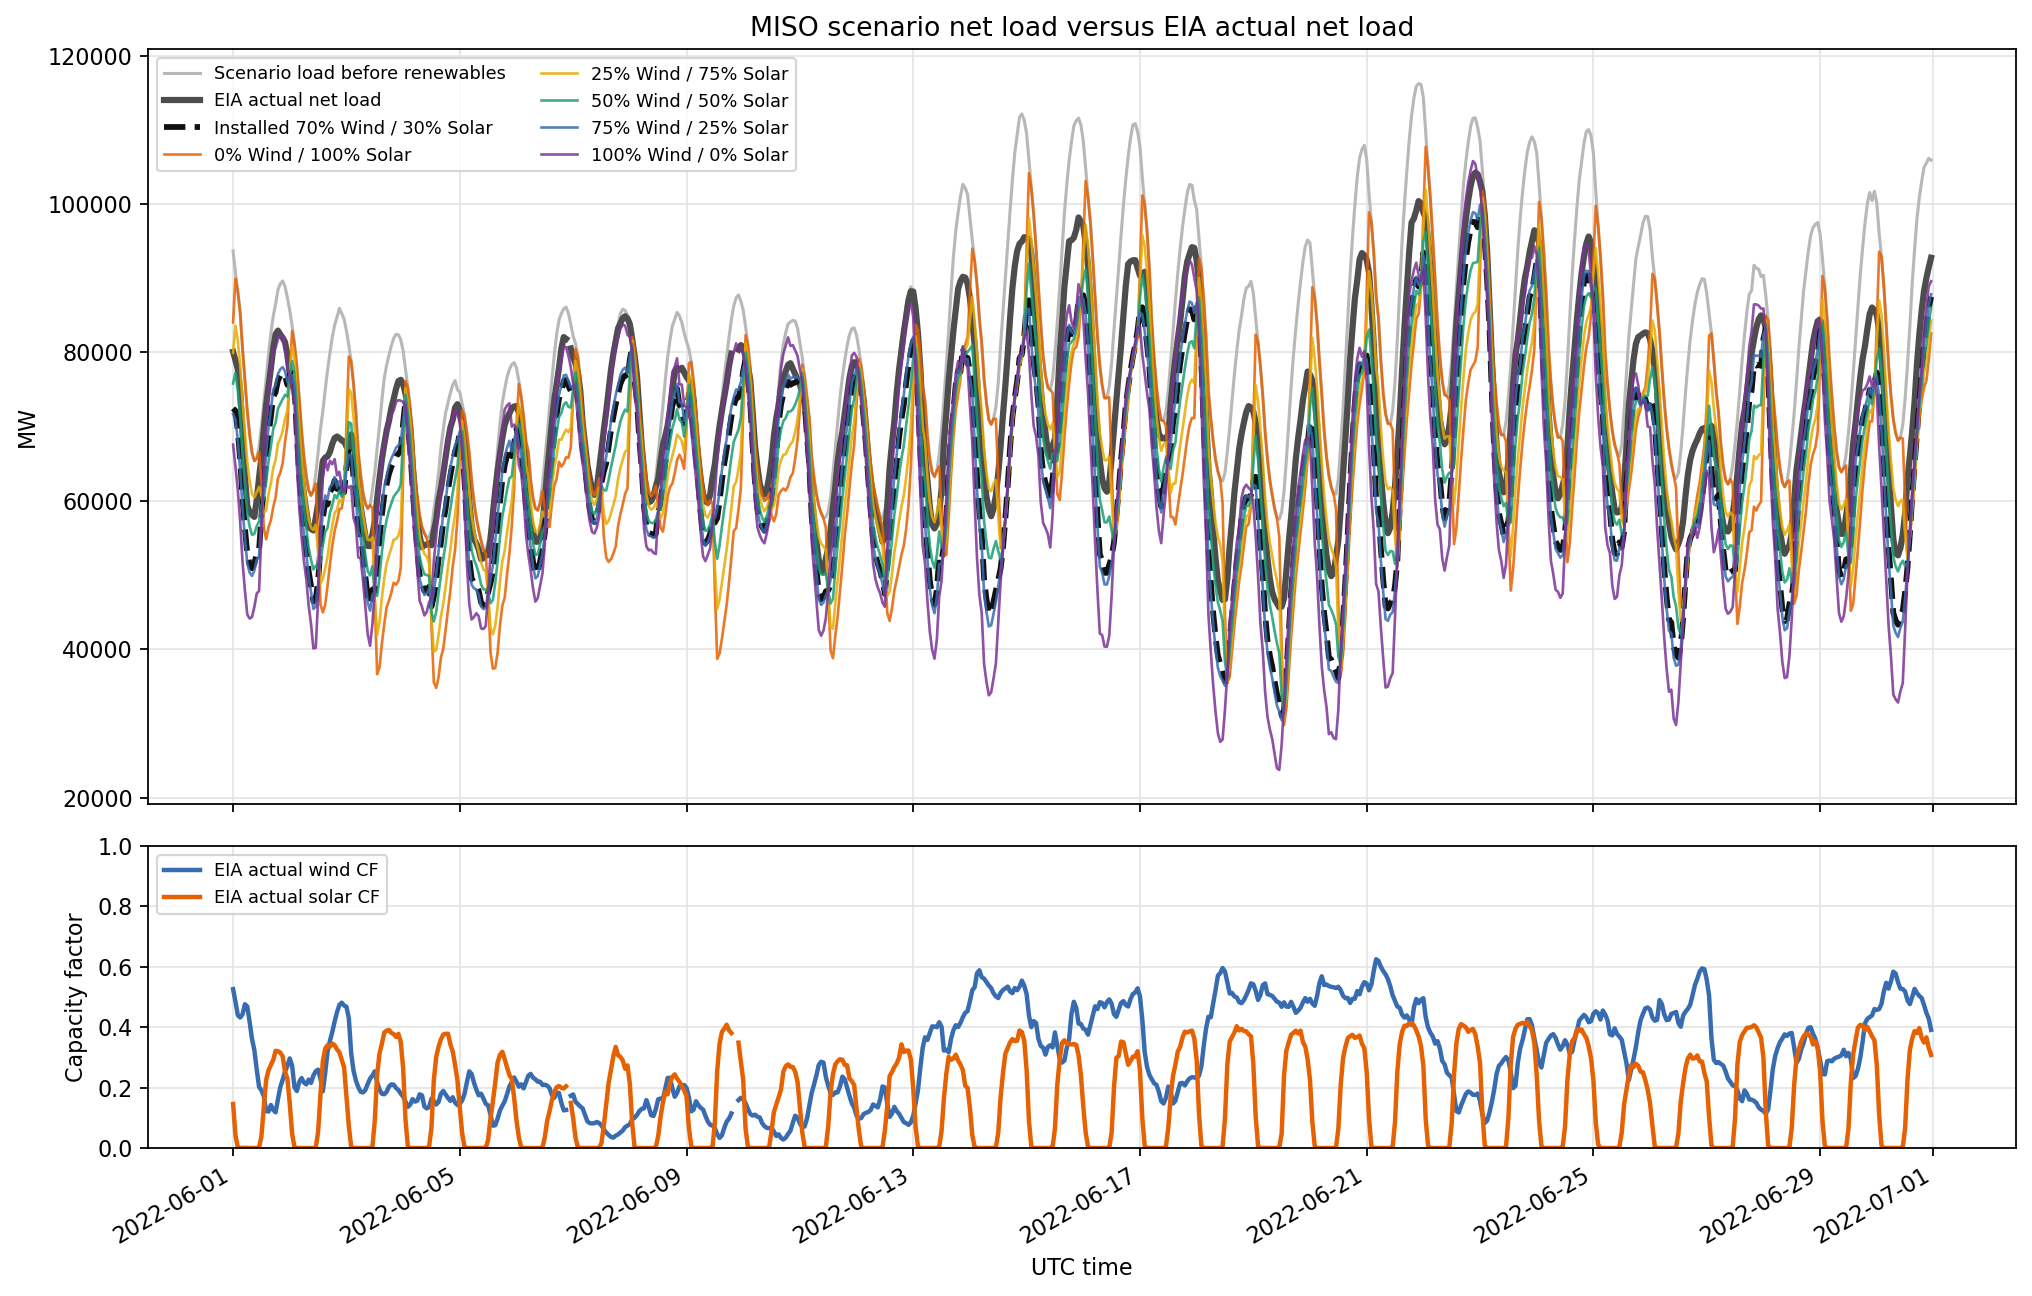

Wrote scenario/EIA plot to notebook_outputs\data_flow\ba_scenario_metrics_generation\plots\MISO_2022-06-01_to_2022-07-01_scenario_vs_eia_actual_net_load_and_cf.png


In [8]:
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Keep scenario colors stable so wind-heavy and solar-heavy cases are easy to track.
SPLIT_SCENARIO_STYLE = {
    "split_w00_s100": ("0% Wind / 100% Solar", "#E66101"),
    "split_w25_s75": ("25% Wind / 75% Solar", "#E6AB02"),
    "split_w50_s50": ("50% Wind / 50% Solar", "#1B9E77"),
    "split_w75_s25": ("75% Wind / 25% Solar", "#386CB0"),
    "split_w100_s00": ("100% Wind / 0% Solar", "#7B3294"),
}

archive_installed_mix = scenario_specs.iloc[0]
archive_installed_label = f"Installed {archive_installed_mix['wind_pct']:.0f}% Wind / {archive_installed_mix['solar_pct']:.0f}% Solar"

SCENARIO_PLOT = PLOT_DIR / f"{BA_CODE}_{PLOT_START_DATE}_to_{PLOT_END_DATE}_scenario_vs_eia_actual_net_load_and_cf.png"

# Apply the same half-open time window to modeled ingredients, scenarios, and observations.
plot_base = base[base["time_utc"].ge(plot_start) & base["time_utc"].lt(plot_end)]
plot_scenarios = notebook_scenarios[notebook_scenarios["time_utc"].ge(plot_start) & notebook_scenarios["time_utc"].lt(plot_end)]
plot_eia = eia_actual_net_load[eia_actual_net_load["time_utc"].ge(plot_start) & eia_actual_net_load["time_utc"].lt(plot_end)]

fig, (ax_net, ax_gen) = plt.subplots(2, 1, figsize=(12.8, 8.2), dpi=160, sharex=True, gridspec_kw={"height_ratios": [2.5, 1.0]})

# Upper panel: demand baseline, observed net load, and all modeled capacity portfolios.
ax_net.plot(plot_base["time_utc"], plot_base["load_mw"], color="#B8B8B8", linewidth=1.4, label="Scenario load before renewables")
ax_net.plot(plot_eia["time_utc"], plot_eia["eia930_net_load_mw"], color="#4D4D4D", linewidth=2.8, label="EIA actual net load")

installed_rows = plot_scenarios[plot_scenarios["scenario"].eq(ARCHIVE_INSTALLED_SCENARIO)]
ax_net.plot(installed_rows["time_utc"], installed_rows["net_load_mw"], color="#111111", linewidth=2.6, linestyle="--", label=archive_installed_label)

for scenario, (label, color) in SPLIT_SCENARIO_STYLE.items():
    scenario_rows = plot_scenarios[plot_scenarios["scenario"].eq(scenario)]
    if not scenario_rows.empty:
        ax_net.plot(scenario_rows["time_utc"], scenario_rows["net_load_mw"], color=color, linewidth=1.2, alpha=0.85, label=label)

ax_net.set(ylabel="MW", title=f"{BA_CODE} scenario net load versus EIA actual net load")
ax_net.legend(loc="upper left", ncol=2, fontsize=8)
ax_net.grid(True, color="#E6E6E6", linewidth=0.8)

# Lower panel: observed resource availability, normalized to comparable 0-1 CF units.
ax_gen.plot(plot_eia["time_utc"], plot_eia["wind_actual_cf"], color="#386CB0", linewidth=2.0, label="EIA actual wind CF")
ax_gen.plot(plot_eia["time_utc"], plot_eia["solar_actual_cf"], color="#E66101", linewidth=2.0, label="EIA actual solar CF")
ax_gen.set(ylabel="Capacity factor", ylim=(0, 1), xlabel="UTC time")
ax_gen.legend(loc="upper left", fontsize=8)
ax_gen.grid(True, color="#E6E6E6", linewidth=0.8)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(SCENARIO_PLOT, bbox_inches="tight")
plt.show()

print(f"Wrote scenario/EIA plot to {SCENARIO_PLOT.relative_to(Path('..'))}")


### Pooled-region proof of concept

This minimal check applies the copper-plate pooling equations to one representative hour. Installed-scenario generation from the six MISO subregions is converted to pooled wind and solar CF; those pooled CF values are then applied to each of the six pooled capacity portfolios. The assertion checks the resulting rows against the packaged `MISO_SUBREGION_SUM` product, which remains the complete time-series source of record.


In [9]:
POOLED_REGION_CODE = "MISO_SUBREGION_SUM"
POOLED_MEMBER_BA_CODES = ["MISO_0001", "MISO_0004", "MISO_0006", "MISO_0027", "MISO_0035", "MISO_8910"]
# One hour is enough to demonstrate and verify the pooling equations for all portfolios.
POOL_EXAMPLE_HOUR = "2021-02-15T12:00:00Z"

input_columns = ["time_utc", "scenario", "load_mw", "wind_mw", "solar_mw"]
# Read the installed-scenario row for each subregion at the representative hour.
member_hour = pd.concat(
    [
        pd.read_csv(
            DATA_ROOT / "ba_scenario_metrics" / f"{ba}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_scenario_metrics.csv",
            usecols=input_columns,
        )
        for ba in POOLED_MEMBER_BA_CODES
    ],
    ignore_index=True,
).query("time_utc == @POOL_EXAMPLE_HOUR and scenario == @ARCHIVE_INSTALLED_SCENARIO")
# Sum member nameplate capacity separately for each installed or synthetic portfolio.
pooled_capacity_by_scenario = (
    ba_scenario_metric_metadata[ba_scenario_metric_metadata["ba_code"].isin(POOLED_MEMBER_BA_CODES)]
    [["ba_code", "scenario", "wind_capacity_mw", "solar_capacity_mw"]].drop_duplicates()
    .groupby("scenario", as_index=False)[["wind_capacity_mw", "solar_capacity_mw"]].sum()
)
installed_capacity = pooled_capacity_by_scenario.query("scenario == @ARCHIVE_INSTALLED_SCENARIO").iloc[0]
# Copper-plate CF is total installed-scenario generation divided by total installed capacity.
pooled_wind_cf = member_hour["wind_mw"].sum() / installed_capacity["wind_capacity_mw"]
pooled_solar_cf = member_hour["solar_mw"].sum() / installed_capacity["solar_capacity_mw"]

# Apply those common pooled CF values to every capacity portfolio; load is unchanged by the split.
pooled_example = pooled_capacity_by_scenario.copy()
pooled_example["time_utc"] = POOL_EXAMPLE_HOUR
pooled_example["load_mw"] = member_hour["load_mw"].sum()
pooled_example["wind_mw"] = pooled_example["wind_capacity_mw"] * pooled_wind_cf
pooled_example["solar_mw"] = pooled_example["solar_capacity_mw"] * pooled_solar_cf
pooled_renewable_mw = pooled_example["wind_mw"] + pooled_example["solar_mw"]
pooled_total_capacity_mw = pooled_example["wind_capacity_mw"] + pooled_example["solar_capacity_mw"]
pooled_example["net_load_mw"] = pooled_example["load_mw"] - pooled_renewable_mw
pooled_example["renew_cf_equiv"] = pooled_renewable_mw / pooled_total_capacity_mw
proof_columns = input_columns + ["net_load_mw", "renew_cf_equiv"]
# The reconstructed six-row example must agree with the packaged pooled product.
packaged_path = DATA_ROOT / "pooled_scenario_metrics" / f"{POOLED_REGION_CODE}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_scenario_metrics.csv"
packaged_example = (
    pd.read_csv(packaged_path, usecols=proof_columns)
    .query("time_utc == @POOL_EXAMPLE_HOUR")
    .sort_values("scenario")
    .reset_index(drop=True)
)
pooled_example = pooled_example[proof_columns].sort_values("scenario").reset_index(drop=True)
pd.testing.assert_frame_equal(pooled_example, packaged_example, check_dtype=False, rtol=1e-5, atol=1e-5)
pooled_example


,time_utc,scenario,load_mw,wind_mw,solar_mw,net_load_mw,renew_cf_equiv
0,2021-02-15T12:00:00Z,installed_2024,91078.79,13553.914311,0.0,77524.875689,0.296419
1,2021-02-15T12:00:00Z,split_w00_s100,91078.79,0.000000,0.0,91078.790000,0.000000
2,2021-02-15T12:00:00Z,split_w100_s00,91078.79,19276.745584,0.0,71802.044416,0.421574
3,2021-02-15T12:00:00Z,split_w25_s75,91078.79,4819.186396,0.0,86259.603604,0.105394
4,2021-02-15T12:00:00Z,split_w50_s50,91078.79,9638.372792,0.0,81440.417208,0.210787
5,2021-02-15T12:00:00Z,split_w75_s25,91078.79,14457.559188,0.0,76621.230812,0.316181


### State-level application

The corresponding state workflows are documented in `state_load_generation.ipynb` and Appendix A of `site_cf_generation_ba_weighting_validation.ipynb`. Packaged state scenario-metrics tables combine their load and renewable-capacity-factor outputs using the same six nameplate-capacity portfolios shown above.
